# Raman Spectrum Plotting and Comparison

This notebook analyzes mode-resolved Raman activities calculated for Li-deficient Ta-doped LLZO garnet structures.

The input files are `vasp_raman.dat` files stored in `data/processed/`. Each file contains discrete phonon-mode Raman activities. The notebook applies Gaussian broadening to construct continuous simulated Raman spectra and compares spectra across:

- Li content: Li5, Li5.5, and Li6.5
- molecular dynamics snapshot time: 50 ps, 75 ps, and 100 ps

The analysis is based on processed outputs from the original first-principles Raman workflow. The original finite-displacement Raman helper scripts are not included in this repository.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# The notebook is expected to be run from the notebooks/ directory.
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures" / "raman"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

systems = {
    "Li6p5": {
        "label": r"Li$_{6.5}$La$_3$Zr$_{1.5}$Ta$_{0.5}$O$_{12}$",
        "folders": {
            "50 ps": "Li6p5_50ps",
            "75 ps": "Li6p5_75ps",
            "100 ps": "Li6p5_100ps",
        },
    },
    "Li5p5": {
        "label": r"Li$_{5.5}$La$_3$Zr$_{1.5}$Ta$_{0.5}$O$_{11.5}$",
        "folders": {
            "50 ps": "Li5p5_50ps",
            "75 ps": "Li5p5_75ps",
            "100 ps": "Li5p5_100ps",
        },
    },
    "Li5": {
        "label": r"Li$_5$La$_3$Zr$_{1.5}$Ta$_{0.5}$O$_{11.25}$",
        "folders": {
            "50 ps": "Li5_50ps",
            "75 ps": "Li5_75ps",
            "100 ps": "Li5_100ps",
        },
    },
}

raman_range = (200, 600)
low_frequency_window = (200, 300)

## Input file format

Each processed folder contains a `vasp_raman.dat` file with the following format:

```text
# mode    freq(cm-1)    alpha    beta2    activity

In [3]:
class SimulatedRaman:
    """Load and broaden mode-resolved Raman activities from a vasp_raman.dat file."""

    def __init__(self, path):
        self.path = Path(path)
        self.file_path = self.path / "vasp_raman.dat"

        if not self.file_path.exists():
            raise FileNotFoundError(f"Could not find Raman file: {self.file_path}")

        self.data = pd.read_csv(
            self.file_path,
            comment="#",
            delim_whitespace=True,
            names=["mode", "frequency_cm1", "alpha", "beta2", "activity"],
        )

        self.data = self.data.sort_values("frequency_cm1").reset_index(drop=True)

    def smeared_spectrum(
        self,
        x=None,
        broadening=20.0,
        normalize=True,
        frequency_range=(0, 900),
        n_points=2000,
    ):
        """Return a Gaussian-broadened Raman spectrum."""
        if x is None:
            x = np.linspace(frequency_range[0], frequency_range[1], n_points)

        y = np.zeros_like(x, dtype=float)

        for _, row in self.data.iterrows():
            frequency = row["frequency_cm1"]
            activity = row["activity"]
            gaussian = np.exp(-((x - frequency) ** 2) / (2 * broadening**2))
            y += activity * gaussian

        if normalize and np.max(y) > 0:
            y = y / np.max(y)

        return x, y

    def area_between(self, lower, upper, broadening=20.0, normalize=True):
        """Calculate area under the broadened spectrum between two frequencies."""
        x, y = self.smeared_spectrum(
            broadening=broadening,
            normalize=normalize,
            frequency_range=(lower, upper),
            n_points=1000,
        )
        return np.trapz(y, x)

    def modes_in_range(self, lower, upper):
        """Return discrete Raman-active modes within a frequency range."""
        mask = (self.data["frequency_cm1"] >= lower) & (self.data["frequency_cm1"] <= upper)
        return self.data.loc[mask].copy()

In [4]:
raman_data = {}

for system_name, system_info in systems.items():
    raman_data[system_name] = {}

    for time_label, folder_name in system_info["folders"].items():
        folder_path = DATA_DIR / folder_name
        raman_data[system_name][time_label] = SimulatedRaman(folder_path)

print("Loaded Raman datasets:")
for system_name, time_data in raman_data.items():
    for time_label, obj in time_data.items():
        n_modes = len(obj.data)
        f_min = obj.data["frequency_cm1"].min()
        f_max = obj.data["frequency_cm1"].max()
        print(f"{system_name:5s} | {time_label:6s} | {n_modes:3d} modes | {f_min:8.2f}–{f_max:8.2f} cm^-1")

Loaded Raman datasets:
Li6p5 | 50 ps  | 195 modes |   203.18–  605.76 cm^-1
Li6p5 | 75 ps  | 195 modes |   191.41–  609.28 cm^-1
Li6p5 | 100 ps | 195 modes |   189.79–  610.10 cm^-1
Li5p5 | 50 ps  | 174 modes |   202.99–  601.48 cm^-1
Li5p5 | 75 ps  | 174 modes |   203.03–  602.67 cm^-1
Li5p5 | 100 ps | 174 modes |   205.51–  595.55 cm^-1
Li5   | 50 ps  | 171 modes |   203.24–  609.20 cm^-1
Li5   | 75 ps  | 171 modes |   203.85–  603.41 cm^-1
Li5   | 100 ps | 171 modes |   202.20–  619.36 cm^-1


In [5]:
summary_rows = []

for system_name, time_data in raman_data.items():
    for time_label, obj in time_data.items():
        modes_200_600 = obj.modes_in_range(*raman_range)
        modes_200_300 = obj.modes_in_range(*low_frequency_window)

        summary_rows.append(
            {
                "system": system_name,
                "time": time_label,
                "n_total_modes": len(obj.data),
                "min_frequency_cm1": obj.data["frequency_cm1"].min(),
                "max_frequency_cm1": obj.data["frequency_cm1"].max(),
                "n_modes_200_600": len(modes_200_600),
                "n_modes_200_300": len(modes_200_300),
            }
        )

summary_df = pd.DataFrame(summary_rows)
summary_df

,system,time,n_total_modes,min_frequency_cm1,max_frequency_cm1,n_modes_200_600,n_modes_200_300
0,Li6p5,50 ps,195,203.18310,605.75899,194,48
1,Li6p5,75 ps,195,191.40859,609.27619,187,47
2,Li6p5,100 ps,195,189.79500,610.09995,189,47
3,Li5p5,50 ps,174,202.98653,601.47661,173,44
4,Li5p5,75 ps,174,203.02747,602.67384,173,45
5,Li5p5,100 ps,174,205.50747,595.54842,174,45
6,Li5,50 ps,171,203.24105,609.20226,170,48
7,Li5,75 ps,171,203.85230,603.41403,169,45
8,Li5,100 ps,171,202.19643,619.35692,167,46


## Data check

The table above summarizes the number of Raman-active modes available for each Li content and MD snapshot time.

The main analysis focuses on the 200–600 cm⁻¹ region because this range was used in the original study to compare Li–O-related vibrational features. A narrower 200–300 cm⁻¹ window is also evaluated because the original analysis observed intensity changes in this lower-frequency region across Li contents.

## Raman spectrum comparison

The following plots use Gaussian broadening to convert the discrete mode-resolved Raman activities into continuous spectra.

The default broadening width is set to 20 cm⁻¹. This value is used for qualitative comparison of the main spectral features across Li contents and MD snapshot times.

In [12]:
def plot_time_comparison_for_system(
    system_name,
    xlim=(0, 900),
    broadening=20.0,
    normalize=True,
    save=True,
):
    """Plot Raman spectra at 50, 75, and 100 ps for one Li stoichiometry."""
    system_label = systems[system_name]["label"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for time_label in ["50 ps", "75 ps", "100 ps"]:
        raman_obj = raman_data[system_name][time_label]
        x, y = raman_obj.smeared_spectrum(
            broadening=broadening,
            normalize=normalize,
            frequency_range=xlim,
            n_points=2000,
        )
        ax.plot(x, y, label=time_label)

    ax.set_xlim(*xlim)
    ax.set_xlabel(r"Raman shift / cm$^{-1}$")
    ax.set_ylabel("Normalized intensity" if normalize else "Intensity / arb. units")
    ax.set_title(f"Calculated Raman spectra for {system_label}")
    ax.legend(frameon=False, title="MD snapshot")
    ax.grid(alpha=0.3)

    fig.tight_layout()

    if save:
        output_name = f"raman_{system_name}_time_comparison.png"
        fig.savefig(FIGURE_DIR / output_name, dpi=300, bbox_inches="tight")

    return fig, ax


def mean_spectrum_for_system(
    system_name,
    xlim=(0, 900),
    broadening=20.0,
    normalize_individual=True,
    normalize_mean=True,
):
    """Calculate the mean Raman spectrum over 50, 75, and 100 ps snapshots."""
    x_common = np.linspace(xlim[0], xlim[1], 2000)
    spectra = []

    for time_label in ["50 ps", "75 ps", "100 ps"]:
        raman_obj = raman_data[system_name][time_label]
        x, y = raman_obj.smeared_spectrum(
            x=x_common,
            broadening=broadening,
            normalize=normalize_individual,
            frequency_range=xlim,
            n_points=2000,
        )
        spectra.append(y)

    spectra = np.array(spectra)
    y_mean = spectra.mean(axis=0)
    y_std = spectra.std(axis=0)

    if normalize_mean and np.max(y_mean) > 0:
        scale = np.max(y_mean)
        y_mean = y_mean / scale
        y_std = y_std / scale

    return x_common, y_mean, y_std


def plot_mean_spectra_across_systems(
    xlim=(0, 900),
    broadening=20.0,
    show_std=False,
    save=True,
):
    """Plot mean Raman spectra for Li6.5, Li5.5, and Li5."""
    fig, ax = plt.subplots(figsize=(8, 5))

    for system_name in ["Li6p5", "Li5p5", "Li5"]:
        x, y_mean, y_std = mean_spectrum_for_system(
            system_name,
            xlim=xlim,
            broadening=broadening,
            normalize_individual=True,
            normalize_mean=True,
        )

        label = systems[system_name]["label"]
        ax.plot(x, y_mean, label=label)

        if show_std:
            ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2)

    ax.set_xlim(*xlim)
    ax.set_xlabel(r"Raman shift / cm$^{-1}$")
    ax.set_ylabel("Mean normalized intensity")
    ax.set_title("Mean calculated Raman spectra across MD snapshots")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

    fig.tight_layout()

    if save:
        output_name = "raman_mean_spectra_by_li_content.png"
        fig.savefig(FIGURE_DIR / output_name, dpi=300, bbox_inches="tight")

    return fig, ax

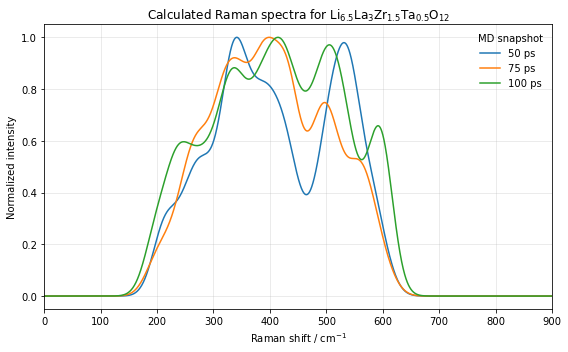

In [13]:
fig, ax = plot_time_comparison_for_system(
    "Li6p5",
    xlim=(0, 900),
    broadening=20.0,
    normalize=True,
)

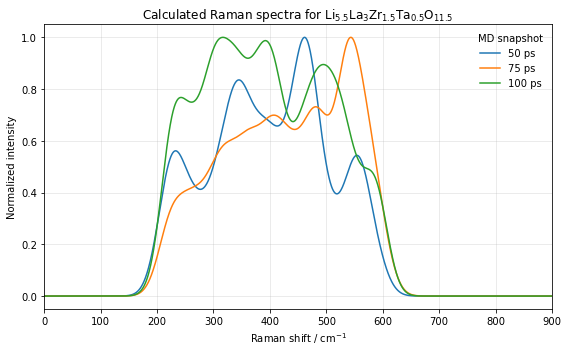

In [14]:
fig, ax = plot_time_comparison_for_system(
    "Li5p5",
    xlim=(0, 900),
    broadening=20.0,
    normalize=True,
)

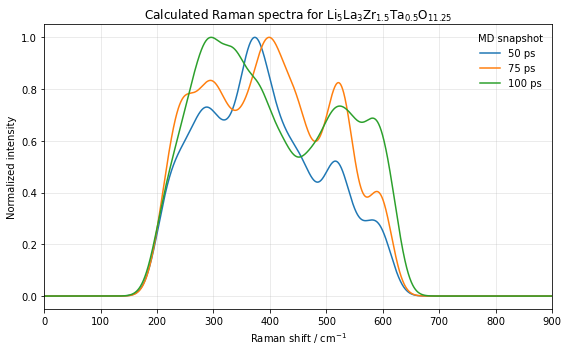

In [15]:
fig, ax = plot_time_comparison_for_system(
    "Li5",
    xlim=(0, 900),
    broadening=20.0,
    normalize=True,
)

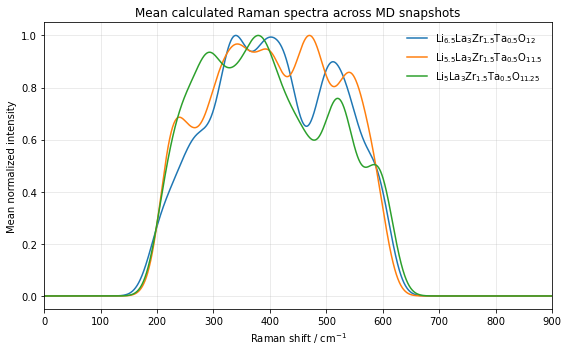

In [16]:
fig, ax = plot_mean_spectra_across_systems(
    xlim=(0, 900),
    broadening=20.0,
    show_std=False,
)